
# GVH Diagonal Cubic 0.2.11 — Covariant GVH Invariant
## Construction et sélection d'un invariant covariant propre à GVH

**Auteur : Charlemagne O Laurince**

---

## Objectif

Les versions précédentes ont établi :

\[
g_{\mu\nu}
\rightarrow
\Gamma^\rho_{\mu\nu}
\rightarrow
R^\rho{}_{\sigma\mu\nu}
\rightarrow
G_{\mu\nu}
\rightarrow
T_{\mu\nu}^{\mathrm{eff}}
\rightarrow
S_{\mathrm{trial}}.
\]

La question centrale devient maintenant :

> Quel objet covariant pourrait représenter l'idée diagonale ou directionnelle de GVH sans dépendre arbitrairement des axes \(x,y,z\) ?

Le notebook construit et compare plusieurs familles d'invariants candidats.

---

## Règle scientifique

Un axe de coordonnées n'est pas un objet physique.

Une expression telle que

\[
I_x-I_y
\]

n'est pas covariante si \(x\) et \(y\) désignent seulement des coordonnées choisies.

Un invariant GVH admissible doit être construit à partir d'objets qui se transforment correctement :

- métrique ;
- champs scalaires ;
- vecteurs ou tenseurs dynamiques ;
- projecteurs ;
- courbure ;
- dérivées covariantes ;
- tétrades munies des symétries appropriées.

---

## Statut

Tous les objets propres à GVH présentés ici sont des **candidats exploratoires**.

Le notebook ne proclame aucun invariant comme fondamental avant validation analytique et numérique.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("SymPy :", sp.__version__)


SymPy : 1.14.0



# 1. Critères obligatoires

Un invariant candidat doit satisfaire autant que possible :

1. **scalarité**
   \[
   \mathcal I'=\mathcal I;
   \]

2. **covariance générale** ;

3. **indépendance des coordonnées** ;

4. **dimensions physiques connues** ;

5. **limite plate contrôlée** ;

6. **limite isotrope contrôlée** ;

7. **compatibilité avec Schwarzschild et FLRW** ;

8. **intégrabilité dans une action**
   \[
   S\supset\int d^4x\sqrt{-g}\,\mathcal I;
   \]

9. **ordre différentiel contrôlé** ;

10. **contenu potentiellement falsifiable**.


In [2]:

criteria = pd.DataFrame([
    {"criterion": "scalar", "critical": True},
    {"criterion": "covariant", "critical": True},
    {"criterion": "coordinate_independent", "critical": True},
    {"criterion": "dimensions_defined", "critical": True},
    {"criterion": "flat_limit", "critical": True},
    {"criterion": "isotropic_limit", "critical": True},
    {"criterion": "action_compatible", "critical": True},
    {"criterion": "derivative_order_controlled", "critical": True},
    {"criterion": "Einstein_limit_possible", "critical": True},
    {"criterion": "falsifiable_content", "critical": False}
])

criteria


,criterion,critical
0,scalar,True
1,covariant,True
2,coordinate_independent,True
3,dimensions_defined,True
4,flat_limit,True
5,isotropic_limit,True
6,action_compatible,True
7,derivative_order_controlled,True
8,Einstein_limit_possible,True
9,falsifiable_content,False



# 2. Invariants géométriques connus

Les invariants standards comprennent :

\[
R,
\]

\[
R_{\mu\nu}R^{\mu\nu},
\]

\[
R_{\mu\nu\rho\sigma}R^{\mu\nu\rho\sigma},
\]

\[
C_{\mu\nu\rho\sigma}C^{\mu\nu\rho\sigma},
\]

et la combinaison de Gauss–Bonnet :

\[
\mathcal G
=
R^2
-
4R_{\mu\nu}R^{\mu\nu}
+
R_{\mu\nu\rho\sigma}R^{\mu\nu\rho\sigma}.
\]

Ils sont covariants, mais aucun ne représente automatiquement l'idée spécifique de « diagonale cubique GVH ».


In [3]:

known_invariants = pd.DataFrame([
    {
        "name": "Ricci scalar R",
        "symbol": "R",
        "derivative_order_metric": 2,
        "dimension_L_power": -2,
        "captures_directionality": False
    },
    {
        "name": "Ricci squared",
        "symbol": "R_mn R^mn",
        "derivative_order_metric": 4,
        "dimension_L_power": -4,
        "captures_directionality": False
    },
    {
        "name": "Kretschmann",
        "symbol": "R_abcd R^abcd",
        "derivative_order_metric": 4,
        "dimension_L_power": -4,
        "captures_directionality": False
    },
    {
        "name": "Weyl squared",
        "symbol": "C_abcd C^abcd",
        "derivative_order_metric": 4,
        "dimension_L_power": -4,
        "captures_directionality": "tidal anisotropy"
    },
    {
        "name": "Gauss-Bonnet",
        "symbol": "G_GB",
        "derivative_order_metric": 4,
        "dimension_L_power": -4,
        "captures_directionality": False
    }
])

known_invariants


,name,symbol,derivative_order_metric,dimension_L_power,captures_directionality
0,Ricci scalar R,R,2,-2,False
1,Ricci squared,R_mn R^mn,4,-4,False
2,Kretschmann,R_abcd R^abcd,4,-4,False
3,Weyl squared,C_abcd C^abcd,4,-4,tidal anisotropy
4,Gauss-Bonnet,G_GB,4,-4,False



# 3. Décomposition covariante par un observateur

Soit un champ de quadrivitesse temporelle normalisé :

\[
u^\mu u_\mu=-1.
\]

Le projecteur spatial orthogonal est :

\[
h_{\mu\nu}
=
g_{\mu\nu}
+
u_\mu u_\nu.
\]

Il permet de définir covariamment :

- expansion
  \[
  \Theta=\nabla_\mu u^\mu;
  \]

- accélération
  \[
  a^\mu=u^\nu\nabla_\nu u^\mu;
  \]

- cisaillement
  \[
  \sigma_{\mu\nu};
  \]

- vorticité
  \[
  \omega_{\mu\nu}.
  \]

Ces objets dépendent du congruence \(u^\mu\), mais pas d'un choix arbitraire d'axes.


In [4]:

eta = sp.diag(-1, 1, 1, 1)

u = sp.Matrix([1, 0, 0, 0])
u_cov = eta*u

h_cov = sp.simplify(
    eta + u_cov*u_cov.T
)

print("u^mu u_mu =")
display(sp.simplify((u.T*eta*u)[0]))

print("Projecteur h_mu_nu =")
display(h_cov)

print("Idempotence spatiale h^mu_nu h^nu_rho = h^mu_rho :")

h_mixed = sp.simplify(eta.inv()*h_cov)
display(sp.simplify(h_mixed*h_mixed-h_mixed))


u^mu u_mu =


-1

Projecteur h_mu_nu =


⎡0  0  0  0⎤
⎢          ⎥
⎢0  1  0  0⎥
⎢          ⎥
⎢0  0  1  0⎥
⎢          ⎥
⎣0  0  0  1⎦

Idempotence spatiale h^mu_nu h^nu_rho = h^mu_rho :


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 4. Champ scalaire et direction temporelle covariante

Un champ scalaire \(\varphi\) définit :

\[
X
=
-\frac12
\nabla_\mu\varphi
\nabla^\mu\varphi.
\]

Lorsque le gradient est temporel, on peut construire :

\[
u_\mu
=
-\frac{\nabla_\mu\varphi}{\sqrt{2X}}.
\]

Cette structure sélectionne une foliation de manière covariante.

Elle pourrait représenter une direction globale ou une variable temporelle effective, mais ne produit pas encore trois temps directionnels indépendants.


In [5]:

g_inv = eta.inv()

phi_t, phi_x, phi_y, phi_z = sp.symbols(
    "phi_t phi_x phi_y phi_z",
    real=True
)

grad_phi_cov = sp.Matrix([
    phi_t,
    phi_x,
    phi_y,
    phi_z
])

X_scalar = sp.simplify(
    -sp.Rational(1, 2)
    * (grad_phi_cov.T*g_inv*grad_phi_cov)[0]
)

print("X =")
display(X_scalar)

timelike_example = sp.simplify(
    X_scalar.subs({
        phi_t: 2,
        phi_x: 1,
        phi_y: 0,
        phi_z: 0
    })
)

print("Exemple temporel X =", timelike_example)


X =


  2     2      2      2
φₜ    φₓ    φ_y    φ_z 
─── - ─── - ──── - ────
 2     2     2      2  

Exemple temporel X = 3/2



# 5. Tenseur directionnel dynamique

Pour représenter une anisotropie ou une « diagonale » sans figer les coordonnées, introduisons un tenseur symétrique dynamique :

\[
D_{\mu\nu}=D_{\nu\mu}.
\]

Décomposition possible :

\[
D_{\mu\nu}
=
\frac13D\,h_{\mu\nu}
+
\bar D_{\mu\nu},
\]

avec :

\[
h^{\mu\nu}\bar D_{\mu\nu}=0,
\qquad
u^\mu\bar D_{\mu\nu}=0.
\]

La partie \(\bar D_{\mu\nu}\) mesure une anisotropie spatiale covariante.


In [6]:

d1, d2, d3 = sp.symbols(
    "d1 d2 d3",
    real=True
)

D_cov = sp.diag(0, d1, d2, d3)
D_mixed = sp.simplify(eta.inv()*D_cov)

D_trace_spatial = sp.simplify(d1+d2+d3)
D_iso = sp.simplify(D_trace_spatial/3)

D_bar_cov = sp.diag(
    0,
    d1-D_iso,
    d2-D_iso,
    d3-D_iso
)

trace_Dbar = sp.simplify(
    sum(
        h_mixed[i,j]*D_bar_cov[j,i]
        for i in range(4)
        for j in range(4)
    )
)

print("D =")
display(D_cov)

print("Partie anisotrope D_bar =")
display(D_bar_cov)

print("Trace spatiale de D_bar =", trace_Dbar)


D =


⎡0  0   0   0 ⎤
⎢             ⎥
⎢0  d₁  0   0 ⎥
⎢             ⎥
⎢0  0   d₂  0 ⎥
⎢             ⎥
⎣0  0   0   d₃⎦

Partie anisotrope D_bar =


⎡0        0                0                 0        ⎤
⎢                                                     ⎥
⎢   2⋅d₁   d₂   d₃                                    ⎥
⎢0  ──── - ── - ──         0                 0        ⎥
⎢    3     3    3                                     ⎥
⎢                                                     ⎥
⎢                     d₁   2⋅d₂   d₃                  ⎥
⎢0        0         - ── + ──── - ──         0        ⎥
⎢                     3     3     3                   ⎥
⎢                                                     ⎥
⎢                                       d₁   d₂   2⋅d₃⎥
⎢0        0                0          - ── - ── + ────⎥
⎣                                       3    3     3  ⎦

Trace spatiale de D_bar = 0



# 6. Invariants candidats

Nous étudions les candidats suivants.

## Candidat A — norme du gradient scalaire

\[
\mathcal I_A
=
\nabla_\mu\varphi\nabla^\mu\varphi.
\]

## Candidat B — norme tensorielle directionnelle

\[
\mathcal I_B
=
D_{\mu\nu}D^{\mu\nu}.
\]

## Candidat C — anisotropie sans trace

\[
\mathcal I_C
=
\bar D_{\mu\nu}\bar D^{\mu\nu}.
\]

## Candidat D — couplage Ricci

\[
\mathcal I_D
=
D_{\mu\nu}R^{\mu\nu}.
\]

## Candidat E — couplage Riemann quadratique directionnel

\[
\mathcal I_E
=
D_{\mu\nu}D_{\rho\sigma}
R^{\mu\rho\nu\sigma}.
\]

## Candidat F — cisaillement du congruence

\[
\mathcal I_F
=
\sigma_{\mu\nu}\sigma^{\mu\nu}.
\]

Aucun n'est retenu comme fondamental à ce stade.


In [7]:

def rank2_norm(metric_cov, tensor_cov):
    metric_inv = sp.simplify(sp.Matrix(metric_cov).inv())
    tensor_cov = sp.Matrix(tensor_cov)
    n = metric_inv.shape[0]

    expr = sp.Integer(0)

    for mu in range(n):
        for nu in range(n):
            for alpha in range(n):
                for beta in range(n):
                    expr += (
                        metric_inv[mu,alpha]
                        * metric_inv[nu,beta]
                        * tensor_cov[mu,nu]
                        * tensor_cov[alpha,beta]
                    )

    return sp.simplify(expr)


I_A = sp.simplify(
    (grad_phi_cov.T*g_inv*grad_phi_cov)[0]
)

I_B = rank2_norm(eta, D_cov)
I_C = rank2_norm(eta, D_bar_cov)

print("I_A =")
display(I_A)

print("I_B =")
display(I_B)

print("I_C =")
display(sp.factor(I_C))


I_A =


    2     2      2      2
- φₜ  + φₓ  + φ_y  + φ_z 

I_B =


  2     2     2
d₁  + d₂  + d₃ 

I_C =


  ⎛  2                     2             2⎞
2⋅⎝d₁  - d₁⋅d₂ - d₁⋅d₃ + d₂  - d₂⋅d₃ + d₃ ⎠
───────────────────────────────────────────
                     3                     


# 7. Propriété clé de l'invariant anisotrope

Pour :

\[
d_1=d_2=d_3,
\]

la partie sans trace s'annule :

\[
\bar D_{\mu\nu}=0,
\]

et donc :

\[
\mathcal I_C=0.
\]

Cela fait de \(\mathcal I_C\) un candidat naturel pour mesurer l'écart à l'isotropie, sans dépendre du nom des axes.


In [8]:

d_iso_symbol = sp.symbols(
    "d_iso_symbol",
    real=True
)

I_C_isotropic = sp.simplify(
    I_C.subs({
        d1: d_iso_symbol,
        d2: d_iso_symbol,
        d3: d_iso_symbol
    })
)

print("I_C en limite isotrope =")
display(I_C_isotropic)

I_C_expanded = sp.factor(I_C)
print("Forme développée/factorisée :")
display(I_C_expanded)


I_C en limite isotrope =


0

Forme développée/factorisée :


  ⎛  2                     2             2⎞
2⋅⎝d₁  - d₁⋅d₂ - d₁⋅d₃ + d₂  - d₂⋅d₃ + d₃ ⎠
───────────────────────────────────────────
                     3                     


# 8. Invariance sous rotation spatiale

Pour une rotation orthogonale \(Q\), le bloc spatial se transforme :

\[
D'\,=\,Q^\mathsf{T}DQ.
\]

Les contractions :

\[
\operatorname{tr}(D),
\qquad
\operatorname{tr}(D^2),
\qquad
\bar D_{ij}\bar D^{ij},
\]

doivent rester invariantes.


In [9]:

rng = np.random.default_rng(1234)

D3 = np.diag([1.0, 2.0, 4.0])

Q_num, _ = np.linalg.qr(
    rng.normal(size=(3,3))
)

if np.linalg.det(Q_num) < 0:
    Q_num[:,0] *= -1

D3_rot = Q_num.T @ D3 @ Q_num

def traceless_norm_3d(matrix):
    trace = np.trace(matrix)
    bar = matrix - trace*np.eye(3)/3
    return np.sum(bar*bar)

rotation_invariants = pd.DataFrame([{
    "trace_original": np.trace(D3),
    "trace_rotated": np.trace(D3_rot),
    "trace_D2_original": np.trace(D3@D3),
    "trace_D2_rotated": np.trace(D3_rot@D3_rot),
    "anisotropy_original": traceless_norm_3d(D3),
    "anisotropy_rotated": traceless_norm_3d(D3_rot)
}])

rotation_invariants["max_error"] = rotation_invariants.apply(
    lambda row: max(
        abs(
            row["trace_original"]
            - row["trace_rotated"]
        ),
        abs(
            row["trace_D2_original"]
            - row["trace_D2_rotated"]
        ),
        abs(
            row["anisotropy_original"]
            - row["anisotropy_rotated"]
        )
    ),
    axis=1
)

rotation_invariants


,trace_original,trace_rotated,trace_D2_original,trace_D2_rotated,anisotropy_original,anisotropy_rotated,max_error
0,7.0,7.0,21.0,21.0,4.666667,4.666667,3.552714e-15



# 9. Test sous boost de Lorentz

Un scalaire construit correctement doit rester invariant sous un boost.

Pour le quadrivecteur covariant \(v_\mu\), la norme :

\[
v_\mu v^\mu
\]

reste inchangée.

Nous vérifions numériquement cette propriété pour le candidat scalaire \(\mathcal I_A\).


In [10]:

def lorentz_boost_x(beta):
    gamma = 1.0/np.sqrt(1.0-beta**2)

    return np.array([
        [gamma, -gamma*beta, 0.0, 0.0],
        [-gamma*beta, gamma, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])


eta_num = np.diag([-1.0, 1.0, 1.0, 1.0])

v_contra = np.array([2.0, 0.7, -0.2, 0.1])
boost = lorentz_boost_x(0.45)
v_boost = boost @ v_contra

norm_before = v_contra @ eta_num @ v_contra
norm_after = v_boost @ eta_num @ v_boost

boost_test_df = pd.DataFrame([{
    "norm_before": norm_before,
    "norm_after": norm_after,
    "absolute_error": abs(norm_after-norm_before)
}])

boost_test_df


,norm_before,norm_after,absolute_error
0,-3.46,-3.46,0.0



# 10. Un faux invariant lié aux axes

Considérons :

\[
J_{\mathrm{bad}}
=
D_{xx}-D_{yy}.
\]

Cette quantité dépend de l'orientation des axes.

Après rotation, elle change généralement. Elle doit donc être rejetée comme invariant physique fondamental.


In [11]:

J_bad_before = D3[0,0]-D3[1,1]
J_bad_after = D3_rot[0,0]-D3_rot[1,1]

bad_axis_df = pd.DataFrame([{
    "J_before": J_bad_before,
    "J_after": J_bad_after,
    "difference": J_bad_after-J_bad_before
}])

bad_axis_df


,J_before,J_after,difference
0,-1.0,0.065926,1.065926



# 11. Cinématique covariante d'un congruence

La dérivée du champ \(u_\mu\) se décompose en :

\[
\nabla_\mu u_\nu
=
\frac13\Theta h_{\mu\nu}
+
\sigma_{\mu\nu}
+
\omega_{\mu\nu}
-
u_\mu a_\nu.
\]

Invariants associés :

\[
\mathcal I_\Theta=\Theta^2,
\]

\[
\mathcal I_\sigma
=
\sigma_{\mu\nu}\sigma^{\mu\nu},
\]

\[
\mathcal I_\omega
=
\omega_{\mu\nu}\omega^{\mu\nu},
\]

\[
\mathcal I_a
=
a_\mu a^\mu.
\]

Ils peuvent mesurer expansion, déformation directionnelle, rotation et non-géodésicité.


In [12]:

Theta_sym = sp.symbols(
    "Theta",
    real=True
)

s1, s2, s3 = sp.symbols(
    "s1 s2 s3",
    real=True
)

sigma_spatial = sp.diag(
    s1,
    s2,
    s3
)

sigma_trace_constraint = sp.Eq(
    s1+s2+s3,
    0
)

I_sigma_3d = sp.simplify(
    s1**2+s2**2+s3**2
)

print("Contrainte de trace du cisaillement :")
display(sigma_trace_constraint)

print("sigma_ij sigma^ij =")
display(I_sigma_3d)


Contrainte de trace du cisaillement :


s₁ + s₂ + s₃ = 0

sigma_ij sigma^ij =


  2     2     2
s₁  + s₂  + s₃ 


# 12. Exemple FLRW

Dans FLRW homogène et isotrope :

\[
\sigma_{\mu\nu}=0,
\qquad
\omega_{\mu\nu}=0,
\qquad
a^\mu=0
\]

pour le congruence comobile.

L'expansion vaut :

\[
\Theta=3H.
\]

Ainsi :

\[
\mathcal I_\sigma=0,
\qquad
\mathcal I_\Theta=9H^2.
\]

Un invariant GVH censé mesurer seulement l'anisotropie devrait s'annuler dans FLRW isotrope.


In [13]:

H = sp.symbols("H", real=True)

FLRW_limits = pd.DataFrame([
    {
        "invariant": "Theta^2",
        "FLRW_value": "9 H^2"
    },
    {
        "invariant": "sigma_mn sigma^mn",
        "FLRW_value": "0"
    },
    {
        "invariant": "omega_mn omega^mn",
        "FLRW_value": "0"
    },
    {
        "invariant": "a_m a^m",
        "FLRW_value": "0"
    },
    {
        "invariant": "Dbar_mn Dbar^mn",
        "FLRW_value": "0 if isotropic"
    }
])

FLRW_limits


,invariant,FLRW_value
0,Theta^2,9 H^2
1,sigma_mn sigma^mn,0
2,omega_mn omega^mn,0
3,a_m a^m,0
4,Dbar_mn Dbar^mn,0 if isotropic



# 13. Exemple Schwarzschild

Schwarzschild est statique et sphériquement symétrique.

Pour les observateurs statiques extérieurs :

- la vorticité est nulle ;
- l'expansion est nulle ;
- le cisaillement du congruence statique est nul ;
- l'accélération propre est non nulle.

La courbure de Weyl est non nulle.

Cela permet de distinguer :

- anisotropie cinématique du congruence ;
- champ tidal gravitationnel ;
- anisotropie d'un tenseur directionnel additionnel.


In [14]:

schwarzschild_limits = pd.DataFrame([
    {"quantity": "Theta", "static_observer": 0},
    {"quantity": "sigma^2", "static_observer": 0},
    {"quantity": "omega^2", "static_observer": 0},
    {"quantity": "a^2", "static_observer": "nonzero"},
    {"quantity": "Weyl^2", "static_observer": "nonzero"},
    {
        "quantity": "Dbar^2",
        "static_observer": (
            "depends on additional GVH field"
        )
    }
])

schwarzschild_limits


,quantity,static_observer
0,Theta,0
1,sigma^2,0
2,omega^2,0
3,a^2,nonzero
4,Weyl^2,nonzero
5,Dbar^2,depends on additional GVH field



# 14. Dimensions physiques

Avec :

\[
[x^\mu]=L,
\qquad
[\nabla_\mu]=L^{-1},
\qquad
[R_{\mu\nu\rho\sigma}]=L^{-2},
\]

les dimensions dépendent du choix de dimension pour les champs.

Si \(D_{\mu\nu}\) est sans dimension :

\[
[\mathcal I_B]=L^0,
\]

\[
[\mathcal I_D]=L^{-2},
\]

\[
[\mathcal I_E]=L^{-2}.
\]

Pour entrer dans une densité lagrangienne gravitationnelle de dimension \(L^{-2}\), \(\mathcal I_B\) doit être multiplié par une échelle de masse ou de longueur appropriée.


In [15]:

dimension_table = pd.DataFrame([
    {
        "candidate": "I_A = grad(phi)^2",
        "L_power_if_phi_dimensionless": -2
    },
    {
        "candidate": "I_B = D_mn D^mn",
        "L_power_if_D_dimensionless": 0
    },
    {
        "candidate": "I_C = Dbar_mn Dbar^mn",
        "L_power_if_D_dimensionless": 0
    },
    {
        "candidate": "I_D = D_mn R^mn",
        "L_power_if_D_dimensionless": -2
    },
    {
        "candidate": "I_E = D D Riemann",
        "L_power_if_D_dimensionless": -2
    },
    {
        "candidate": "I_sigma = sigma_mn sigma^mn",
        "L_power": -2
    },
    {
        "candidate": "Theta^2",
        "L_power": -2
    }
])

dimension_table


,candidate,L_power_if_phi_dimensionless,L_power_if_D_dimensionless,L_power
0,I_A = grad(phi)^2,-2.0,NaN,NaN
1,I_B = D_mn D^mn,NaN,0.0,NaN
2,I_C = Dbar_mn Dbar^mn,NaN,0.0,NaN
3,I_D = D_mn R^mn,NaN,-2.0,NaN
4,I_E = D D Riemann,NaN,-2.0,NaN
5,I_sigma = sigma_mn sigma^mn,NaN,NaN,-2.0
6,Theta^2,NaN,NaN,-2.0



# 15. Compatibilité avec une action

Une action de travail pourrait contenir :

\[
S
=
S_{\mathrm{EH}}
+
\int d^4x\sqrt{-g}
\left[
-\frac{\mu_D^2}{2}\mathcal I_C
+
\lambda_D\mathcal I_D
+
\lambda_\sigma\mathcal I_\sigma
\right].
\]

Questions obligatoires :

1. \(D_{\mu\nu}\) est-il dynamique ?
2. Quelle est sa cinétique ?
3. Quelles contraintes réduisent ses composantes ?
4. Combien de degrés de liberté se propagent ?
5. Existe-t-il des ghosts ?
6. L'isotropie est-elle une solution stable ?
7. La limite d'Einstein est-elle obtenue lorsque les couplages s'annulent ?


In [16]:

candidate_action_terms = pd.DataFrame([
    {
        "term": "mu_D^2 Dbar_mn Dbar^mn",
        "covariant": True,
        "derivative_order": 0,
        "role": "anisotropy potential",
        "main_risk": "no dynamics alone"
    },
    {
        "term": "D_mn R^mn",
        "covariant": True,
        "derivative_order": 2,
        "role": "curvature coupling",
        "main_risk": "extra DOF / constraints"
    },
    {
        "term": "D D Riemann",
        "covariant": True,
        "derivative_order": 2,
        "role": "directional tidal coupling",
        "main_risk": "complex field equations"
    },
    {
        "term": "sigma_mn sigma^mn",
        "covariant": True,
        "derivative_order": 2,
        "role": "congruence shear",
        "main_risk": "depends on u^mu dynamics"
    },
    {
        "term": "(grad phi)^2",
        "covariant": True,
        "derivative_order": 1,
        "role": "scalar kinetic",
        "main_risk": "not specifically cubic"
    }
])

candidate_action_terms


,term,covariant,derivative_order,role,main_risk
0,mu_D^2 Dbar_mn Dbar^mn,True,0,anisotropy potential,no dynamics alone
1,D_mn R^mn,True,2,curvature coupling,extra DOF / constraints
2,D D Riemann,True,2,directional tidal coupling,complex field equations
3,sigma_mn sigma^mn,True,2,congruence shear,depends on u^mu dynamics
4,(grad phi)^2,True,1,scalar kinetic,not specifically cubic



# 16. Tétrades et diagonale locale

Une tétrade \(e^a{}_\mu\) satisfait :

\[
g_{\mu\nu}
=
\eta_{ab}
e^a{}_\mu e^b{}_\nu.
\]

Elle fournit une base locale orthonormée.

Cependant, les rotations locales de Lorentz :

\[
e^a{}_\mu
\rightarrow
\Lambda^a{}_b(x)e^b{}_\mu
\]

ne doivent pas modifier les observables.

Une « diagonale cubique » fondée sur une tétrade doit donc être invariante sous cette jauge locale, ou la théorie doit expliquer pourquoi cette symétrie est modifiée.


In [17]:

tetrad_options = pd.DataFrame([
    {
        "construction": "fixed tetrad components",
        "local_Lorentz_invariant": False,
        "status": "REJECT"
    },
    {
        "construction": "metric contractions of tetrad",
        "local_Lorentz_invariant": True,
        "status": "known geometry"
    },
    {
        "construction": "dynamical tetrad with invariant action",
        "local_Lorentz_invariant": "model dependent",
        "status": "CHECK"
    },
    {
        "construction": "tetrad plus internal tensor",
        "local_Lorentz_invariant": "possible",
        "status": "CHECK"
    }
])

tetrad_options


,construction,local_Lorentz_invariant,status
0,fixed tetrad components,False,REJECT
1,metric contractions of tetrad,True,known geometry
2,dynamical tetrad with invariant action,model dependent,CHECK
3,tetrad plus internal tensor,possible,CHECK



# 17. Classement préliminaire des invariants

Nous attribuons des critères qualitatifs aux candidats.

Le classement est volontairement conservateur :

- `PASS-BASE` : objet covariant valide comme brique mathématique ;
- `CHECK-GVH` : candidat possible, mais contenu GVH non démontré ;
- `REJECT` : dépendance explicite aux axes ou défaut structurel.


In [18]:

candidate_audit = pd.DataFrame([
    {
        "candidate": "I_A = grad(phi)^2",
        "scalar": True,
        "covariant": True,
        "isotropic_limit": True,
        "action_compatible": True,
        "GVH_specific": False,
        "status": "PASS-BASE"
    },
    {
        "candidate": "I_B = D_mn D^mn",
        "scalar": True,
        "covariant": True,
        "isotropic_limit": "nonzero generally",
        "action_compatible": True,
        "GVH_specific": "possible",
        "status": "CHECK-GVH"
    },
    {
        "candidate": "I_C = Dbar_mn Dbar^mn",
        "scalar": True,
        "covariant": True,
        "isotropic_limit": 0,
        "action_compatible": True,
        "GVH_specific": "strong candidate",
        "status": "CHECK-GVH"
    },
    {
        "candidate": "I_D = D_mn R^mn",
        "scalar": True,
        "covariant": True,
        "isotropic_limit": "model dependent",
        "action_compatible": True,
        "GVH_specific": "possible",
        "status": "CHECK-GVH"
    },
    {
        "candidate": "I_E = D D Riemann",
        "scalar": True,
        "covariant": True,
        "isotropic_limit": "model dependent",
        "action_compatible": True,
        "GVH_specific": "possible tidal",
        "status": "CHECK-GVH"
    },
    {
        "candidate": "I_sigma = sigma_mn sigma^mn",
        "scalar": True,
        "covariant": True,
        "isotropic_limit": 0,
        "action_compatible": True,
        "GVH_specific": False,
        "status": "PASS-BASE"
    },
    {
        "candidate": "D_xx - D_yy",
        "scalar": False,
        "covariant": False,
        "isotropic_limit": 0,
        "action_compatible": False,
        "GVH_specific": "coordinate artifact",
        "status": "REJECT"
    }
])

candidate_audit


,candidate,scalar,covariant,isotropic_limit,action_compatible,GVH_specific,status
0,I_A = grad(phi)^2,True,True,True,True,False,PASS-BASE
1,I_B = D_mn D^mn,True,True,nonzero generally,True,possible,CHECK-GVH
2,I_C = Dbar_mn Dbar^mn,True,True,0,True,strong candidate,CHECK-GVH
3,I_D = D_mn R^mn,True,True,model dependent,True,possible,CHECK-GVH
4,I_E = D D Riemann,True,True,model dependent,True,possible tidal,CHECK-GVH
5,I_sigma = sigma_mn sigma^mn,True,True,0,True,False,PASS-BASE
6,D_xx - D_yy,False,False,0,False,coordinate artifact,REJECT



# 18. Proposition centrale de travail

Le candidat le plus directement relié à l'idée de directions différentes tout en restant covariant est :

\[
\boxed{
\mathcal I_{\mathrm{GVH}}^{(0)}
=
\bar D_{\mu\nu}\bar D^{\mu\nu}
}
\]

où :

\[
\bar D_{\mu\nu}
=
h_\mu{}^\alpha
h_\nu{}^\beta
D_{\alpha\beta}
-
\frac13
h_{\mu\nu}
h^{\alpha\beta}D_{\alpha\beta}.
\]

Propriétés :

1. scalaire ;
2. covariant ;
3. positif dans une base spatiale euclidienne locale ;
4. nul lorsque les trois directions sont isotropes ;
5. indépendant du nom des axes ;
6. compatible avec une action.

Mais il reste à définir :

- l'origine de \(D_{\mu\nu}\) ;
- sa cinétique ;
- ses contraintes ;
- sa relation avec les observables GVH ;
- sa transformation complète ;
- son rôle dans les limites relativistes.


In [19]:

def anisotropy_invariant_from_eigenvalues(values):
    values = np.asarray(values, dtype=float)
    mean = values.mean()
    return np.sum((values-mean)**2)


examples = pd.DataFrame([
    {
        "case": "isotropic",
        "d1": 1.0,
        "d2": 1.0,
        "d3": 1.0
    },
    {
        "case": "weak anisotropy",
        "d1": 1.0,
        "d2": 1.05,
        "d3": 0.95
    },
    {
        "case": "strong anisotropy",
        "d1": 1.0,
        "d2": 2.0,
        "d3": 4.0
    }
])

examples["I_GVH_0"] = examples.apply(
    lambda row: anisotropy_invariant_from_eigenvalues(
        [row["d1"], row["d2"], row["d3"]]
    ),
    axis=1
)

examples


,case,d1,d2,d3,I_GVH_0
0,isotropic,1.0,1.00,1.00,0.000000
1,weak anisotropy,1.0,1.05,0.95,0.005000
2,strong anisotropy,1.0,2.00,4.00,4.666667


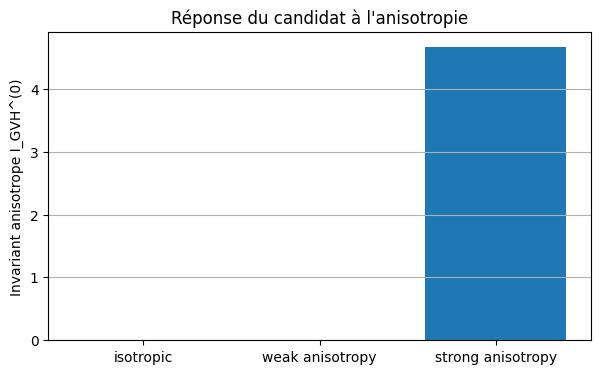

In [20]:

plt.figure(figsize=(7,4))
plt.bar(
    examples["case"],
    examples["I_GVH_0"]
)
plt.ylabel("Invariant anisotrope I_GVH^(0)")
plt.title("Réponse du candidat à l'anisotropie")
plt.grid(True, axis="y")
plt.show()



# 19. Relation candidate avec les observables GVH

Le noyau GVH validé utilise des transitions d'état :

\[
\Delta\widetilde X_k,
\qquad
D_T(k)
=
\|\Delta\widetilde X_k\|.
\]

Une extension géométrique pourrait comparer :

\[
D_T^2
\]

à une contraction locale d'un tenseur directionnel :

\[
D_T^2
\sim
D_{\mu\nu}
\Delta X^\mu
\Delta X^\nu.
\]

Cette relation est seulement une piste.

Elle doit respecter la séparation entre :

- noyau GVH invariant déjà défini ;
- implémentation physique propre au domaine ;
- nouvelle structure tensorielle exploratoire.



# 20. Tests nécessaires avant intégration dans l'action

Le candidat

\[
\mathcal I_{\mathrm{GVH}}^{(0)}
=
\bar D_{\mu\nu}\bar D^{\mu\nu}
\]

doit encore passer :

1. covariance générale explicite ;
2. invariance locale de Lorentz si tétrades utilisées ;
3. comptage des degrés de liberté ;
4. analyse hamiltonienne ;
5. action quadratique ;
6. absence de ghosts ;
7. stabilité de la solution isotrope ;
8. limite de Minkowski ;
9. limite de Schwarzschild ;
10. limite FLRW ;
11. limite newtonienne ;
12. lien quantitatif avec une observable GVH.



# 21. Validation automatisée

Nous validons ici seulement l'infrastructure mathématique :

- projecteur spatial ;
- annulation isotrope de \(\bar D^2\) ;
- invariance sous rotation ;
- invariance de la norme sous boost ;
- non-invariance du faux candidat lié aux axes.


In [21]:

projector_ok = (
    sp.simplify(
        h_mixed*h_mixed-h_mixed
    )
    == sp.zeros(4)
)

isotropic_zero_ok = (
    sp.simplify(I_C_isotropic) == 0
)

rotation_error = float(
    rotation_invariants.loc[0, "max_error"]
)

boost_error = float(
    boost_test_df.loc[0, "absolute_error"]
)

bad_axis_changes = (
    abs(float(bad_axis_df.loc[0, "difference"]))
    > 1e-8
)

validation_rows = [
    {
        "test": "Projecteur spatial idempotent",
        "value": 0.0 if projector_ok else 1.0,
        "threshold": 0.0,
        "status": "PASS" if projector_ok else "FAIL"
    },
    {
        "test": "Invariant anisotrope nul isotropie",
        "value": 0.0 if isotropic_zero_ok else 1.0,
        "threshold": 0.0,
        "status": (
            "PASS"
            if isotropic_zero_ok
            else "FAIL"
        )
    },
    {
        "test": "Invariance sous rotation",
        "value": rotation_error,
        "threshold": 1e-12,
        "status": (
            "PASS"
            if rotation_error < 1e-12
            else "CHECK"
        )
    },
    {
        "test": "Norme sous boost",
        "value": boost_error,
        "threshold": 1e-12,
        "status": (
            "PASS"
            if boost_error < 1e-12
            else "CHECK"
        )
    },
    {
        "test": "Faux invariant détecté",
        "value": 1.0 if bad_axis_changes else 0.0,
        "threshold": 1.0,
        "status": (
            "PASS"
            if bad_axis_changes
            else "FAIL"
        )
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df


,test,value,threshold,status
0,Projecteur spatial idempotent,0.000000e+00,0.000000e+00,PASS
1,Invariant anisotrope nul isotropie,0.000000e+00,0.000000e+00,PASS
2,Invariance sous rotation,3.552714e-15,1.000000e-12,PASS
3,Norme sous boost,0.000000e+00,1.000000e-12,PASS
4,Faux invariant détecté,1.000000e+00,1.000000e+00,PASS


In [22]:

overall_status = (
    "PASS"
    if (validation_df["status"] == "PASS").all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :", overall_status)


STATUT DU NOTEBOOK : PASS



# 22. Export des résultats


In [23]:

import json
from pathlib import Path

audit_path = Path(
    "GVH_Diagonal_Cubic_0.2.11_Invariant_Audit.csv"
)

validation_path = Path(
    "GVH_Diagonal_Cubic_0.2.11_Validation.csv"
)

examples_path = Path(
    "GVH_Diagonal_Cubic_0.2.11_Anisotropy_Examples.csv"
)

metadata_path = Path(
    "GVH_Diagonal_Cubic_0.2.11_Metadata.json"
)

candidate_audit.to_csv(audit_path, index=False)
validation_df.to_csv(validation_path, index=False)
examples.to_csv(examples_path, index=False)

metadata = {
    "notebook_status": overall_status,
    "preferred_candidate": (
        "I_GVH_0 = Dbar_mn Dbar^mn"
    ),
    "candidate_status": "exploratory",
    "D_tensor_origin": "not yet defined",
    "action_status": "not yet derived",
    "ghost_status": "not yet tested"
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés :")
print(audit_path)
print(validation_path)
print(examples_path)
print(metadata_path)


Exports terminés :
GVH_Diagonal_Cubic_0.2.11_Invariant_Audit.csv
GVH_Diagonal_Cubic_0.2.11_Validation.csv
GVH_Diagonal_Cubic_0.2.11_Anisotropy_Examples.csv
GVH_Diagonal_Cubic_0.2.11_Metadata.json



# 23. Décision scientifique

Le notebook ne démontre pas encore l'existence d'un invariant GVH fondamental.

Il identifie toutefois un candidat mathématiquement cohérent :

\[
\boxed{
\mathcal I_{\mathrm{GVH}}^{(0)}
=
\bar D_{\mu\nu}\bar D^{\mu\nu}
}
\]

Ce candidat mesure une anisotropie directionnelle sans sélectionner directement les axes \(x,y,z\).

Sa valeur s'annule dans la limite isotrope.

Il reste classé :

\[
\boxed{\texttt{CHECK-GVH}}
\]

jusqu'à ce que \(D_{\mu\nu}\) soit dérivé à partir d'un principe physique clair.

---

## Ce qui serait nouveau

Le contenu nouveau ne réside pas dans la simple contraction tensorielle, qui est standard.

Il devrait résider dans :

1. la définition physique de \(D_{\mu\nu}\) ;
2. sa relation aux transitions GVH ;
3. sa dynamique ;
4. ses couplages ;
5. une prédiction falsifiable.



# 24. Conclusion et prochaine étape

Cette version transforme l'idée de directions cubiques fixes en un problème tensoriel covariant.

La progression obtenue est :

\[
(x,y,z)
\quad\longrightarrow\quad
D_{\mu\nu}
\quad\longrightarrow\quad
\bar D_{\mu\nu}
\quad\longrightarrow\quad
\bar D_{\mu\nu}\bar D^{\mu\nu}.
\]

Le notebook fournit :

1. critères d'un invariant GVH ;
2. inventaire des invariants connus ;
3. projecteur spatial ;
4. structure scalaire–tenseur ;
5. tenseur directionnel dynamique ;
6. invariants candidats ;
7. tests de rotation ;
8. test de boost ;
9. rejet des expressions dépendantes des axes ;
10. limites FLRW et Schwarzschild ;
11. analyse dimensionnelle ;
12. compatibilité avec l'action ;
13. candidat central provisoire ;
14. validation et exports.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.12\_Directional\_Tensor\_Dynamics.ipynb}
}
\]

Elle devra définir une dynamique pour \(D_{\mu\nu}\) :

- action cinétique ;
- contraintes de symétrie et de trace ;
- équations d'Euler–Lagrange ;
- solution isotrope ;
- perturbations de \(\bar D_{\mu\nu}\) ;
- comptage des degrés de liberté ;
- absence de ghosts ;
- relation avec \(D_T\) et les observables GVH.
